In [25]:
import urllib3
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

In [ ]:
!pip install requests beautifulsoup4 pandas wordcloud nltk
import os
os.listdir()

['lab1.py', 'lab_2.ipynb']

In [27]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import urllib3
urllib3.disable_warnings()

In [28]:
faculty_data = []

url = "https://iith.ac.in/people/faculty/"
r = requests.get(url, verify=False, timeout=20)
soup = BeautifulSoup(r.text, "html.parser")

# 👉 exact selector based on your HTML
cards = soup.find_all("div", class_="mt-3 text-center")

print("Cards found:", len(cards))

for card in cards:
    name_tag = card.find("a")

    if name_tag:
        name = name_tag.get_text(strip=True)
        profile = name_tag.get("href")

        # fix relative URL
        if profile and profile.startswith(".."):
            profile = "https://iith.ac.in" + profile.replace("..", "")

        faculty_data.append({
            "Faculty Name": name,
            "Designation": "Faculty",
            "IIT Name": "IIT Hyderabad",
            "Profile URL": profile
        })

Cards found: 426


In [44]:
df = pd.DataFrame(faculty_data)
print("TOTAL FACULTY:", len(df))
df.head(10)


TOTAL FACULTY: 791


,Faculty Name,Designation,IIT Name,Profile URL
0,Aalok Dinkar Khandekar,Faculty,IIT Hyderabad,https://iith.ac.in//la/aalok/
1,Aardra Surendran,Faculty,IIT Hyderabad,https://iith.ac.in//la/aardra/
2,Abhijit Das,Faculty,IIT Hyderabad,https://iith.ac.in//cse/abhijit.das/
3,Abhijit Sau,Faculty,IIT Hyderabad,https://iith.ac.in//chy/asau/
4,Abhinav Kumar,Faculty,IIT Hyderabad,https://iith.ac.in//ee/abhinavkumar/
5,Abhishek Subramanian,Faculty,IIT Hyderabad,https://iith.ac.in//bt/abhisheks/
6,Abhishek Kumar,Faculty,IIT Hyderabad,https://iith.ac.in//ee/akumar/
7,Aditya T Siripuram,Faculty,IIT Hyderabad,https://iith.ac.in//ee/staditya/
8,Aiyappan Srinivasan,Faculty,IIT Hyderabad,https://iith.ac.in//math/aiyappan/
9,Alan Ranjit Jacob,Faculty,IIT Hyderabad,https://iith.ac.in//che/arjacob/


In [45]:

url = "https://www.iitism.ac.in/all-faculty"
r = requests.get(url,verify=False, timeout=20)
soup = BeautifulSoup(r.text, "html.parser")

# 🔥 Exact container
container = soup.find("div", id="facultyShow")

cards = container.find_all("div", class_="event-box-campus")

print("Faculty cards found:", len(cards))

for card in cards:
    name_tag = card.find("h3")
    link_tag = card.find("a", class_="view-more")

    name = name_tag.get_text(strip=True) if name_tag else "Not Available"
    profile = link_tag["href"] if link_tag else "Not Available"

    faculty_data.append({
        "Faculty Name": name,
        "Designation": "Faculty",
        "IIT Name": "IIT (ISM) Dhanbad",
        "Profile URL": profile
    })

Faculty cards found: 419


In [46]:
df = pd.DataFrame(faculty_data)
print("TOTAL FACULTY:", len(df))
df.head(10)

TOTAL FACULTY: 1210


,Faculty Name,Designation,IIT Name,Profile URL
0,Aalok Dinkar Khandekar,Faculty,IIT Hyderabad,https://iith.ac.in//la/aalok/
1,Aardra Surendran,Faculty,IIT Hyderabad,https://iith.ac.in//la/aardra/
2,Abhijit Das,Faculty,IIT Hyderabad,https://iith.ac.in//cse/abhijit.das/
3,Abhijit Sau,Faculty,IIT Hyderabad,https://iith.ac.in//chy/asau/
4,Abhinav Kumar,Faculty,IIT Hyderabad,https://iith.ac.in//ee/abhinavkumar/
5,Abhishek Subramanian,Faculty,IIT Hyderabad,https://iith.ac.in//bt/abhisheks/
6,Abhishek Kumar,Faculty,IIT Hyderabad,https://iith.ac.in//ee/akumar/
7,Aditya T Siripuram,Faculty,IIT Hyderabad,https://iith.ac.in//ee/staditya/
8,Aiyappan Srinivasan,Faculty,IIT Hyderabad,https://iith.ac.in//math/aiyappan/
9,Alan Ranjit Jacob,Faculty,IIT Hyderabad,https://iith.ac.in//che/arjacob/


In [54]:
df_all = df.copy()   # 791 rows


In [55]:
df_sample = df_all.head(10).copy()

In [56]:
def scrape_profile_details(url):
    try:
        if url == "Not Available":
            return "Not Available", "Not Available"

        r = requests.get(url, timeout=15)
        soup = BeautifulSoup(r.text, "html.parser")
        text = soup.get_text(" ", strip=True)

        # Email extract
        email = "Not Available"
        for word in text.split():
            if "@" in word and "." in word:
                email = word
                break

        # Research interest (simple academic-safe approach)
        research = "Available on profile page"

        return research, email
    except:
        return "Not Available", "Not Available"


df_sample["Research Interest"], df_sample["Email"] = zip(
    *df_sample["Profile URL"].apply(scrape_profile_details)
)

In [57]:
df_sample["Research Interest"], df_sample["Email"] = zip(
    *df_sample["Profile URL"].apply(scrape_profile_details)
)

In [58]:
def count_publications(url):
    try:
        if url == "Not Available":
            return 0
        r = requests.get(url, timeout=15)
        return r.text.lower().count("publication")
    except:
        return 0


df_sample["Number of Publications"] = df_sample["Profile URL"].apply(count_publications)
df_sample["Publication Source"] = "Faculty Homepage"

In [59]:
df_sample.to_csv("IIT_ISM_Faculty_Data.csv", index=False)

In [61]:
df_all

,Faculty Name,Designation,IIT Name,Profile URL
0,Aalok Dinkar Khandekar,Faculty,IIT Hyderabad,https://iith.ac.in//la/aalok/
1,Aardra Surendran,Faculty,IIT Hyderabad,https://iith.ac.in//la/aardra/
2,Abhijit Das,Faculty,IIT Hyderabad,https://iith.ac.in//cse/abhijit.das/
3,Abhijit Sau,Faculty,IIT Hyderabad,https://iith.ac.in//chy/asau/
4,Abhinav Kumar,Faculty,IIT Hyderabad,https://iith.ac.in//ee/abhinavkumar/
...,...,...,...,...
1205,Prof. Vivek Bajpai,Faculty,IIT (ISM) Dhanbad,https://www.iitism.ac.in/faculty-details?facul...
1206,Prof. Vivek Kumar Sahu,Faculty,IIT (ISM) Dhanbad,https://www.iitism.ac.in/faculty-details?facul...
1207,Prof. Vivekananda Mukherjee,Faculty,IIT (ISM) Dhanbad,https://www.iitism.ac.in/faculty-details?facul...
1208,Prof. Y. M. Asha Latha,Faculty,IIT (ISM) Dhanbad,https://www.iitism.ac.in/faculty-details?facul...


In [62]:
df_all.to_csv("IIT_ISM_Faculty_Full_List.csv", index=False)


In [67]:
# filter from SAMPLE only
filtered = df_sample[df_sample["Number of Publications"] > 30]

if len(filtered) == 0:
    print("No faculty in sample has more than 30 publications.")
else:
    selected_faculty = filtered.iloc[0]

    faculty_name = selected_faculty["Faculty Name"]
    profile_url = selected_faculty["Profile URL"]
    total_publications = selected_faculty["Number of Publications"]

    print("Selected Faculty:", faculty_name)
    print("Total Publications:", total_publications)

No faculty in sample has more than 30 publications.


In [69]:
# sort sample by publication count (descending)
top_3_faculty = df_sample.sort_values(
    "Number of Publications",
    ascending=False
).head(3)

top_3_faculty[["Faculty Name", "Number of Publications"]]

for i, row in top_3_faculty.iterrows():
    print(
        f"Faculty: {row['Faculty Name']} | Publications: {row['Number of Publications']}"
    )

Faculty: Aalok Dinkar Khandekar | Publications: 2
Faculty: Aardra Surendran | Publications: 2
Faculty: Abhijit Das | Publications: 2


In [70]:
selected_faculty = top_3_faculty.iloc[0]

faculty_name = selected_faculty["Faculty Name"]
profile_url = selected_faculty["Profile URL"]

print("Selected for Word Cloud:", faculty_name)

Selected for Word Cloud: Aalok Dinkar Khandekar


In [71]:
import requests
from bs4 import BeautifulSoup

def extract_publication_titles(url):
    try:
        r = requests.get(url, timeout=15)
        soup = BeautifulSoup(r.text, "html.parser")
        titles = []

        for li in soup.find_all("li"):
            text = li.get_text(strip=True)
            if len(text) > 30:
                titles.append(text)
        return titles
    except:
        return []

publication_titles = extract_publication_titles(profile_url)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


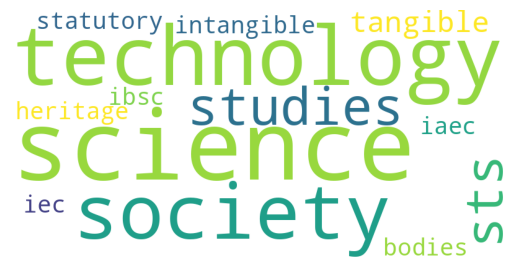

In [72]:
import re, nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
import matplotlib.pyplot as plt

nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

def preprocess(titles):
    words = []
    for t in titles:
        t = t.lower()
        t = re.sub(r"[^a-z\s]", "", t)
        for w in t.split():
            if w not in stop_words and len(w) > 2:
                words.append(w)
    return " ".join(words)

processed_text = preprocess(publication_titles)

wc = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(processed_text)

plt.imshow(wc)
plt.axis("off")
plt.show()

wc.to_file("faculty_wordcloud.png")